<a href="https://colab.research.google.com/github/radha-mourya/Customer--satisfaction--analysis/blob/main/Copy_of_customer_satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **STEP 1: IMPORTING LIBRARIES, LOADING DATA & PREPROCESSING**

### **1.1 Import required Libraries**

In [ ]:
# Importing required libraries for data handles, data visualization, machine learings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Explanation:
These libraries helps us load, clean, analyze, visualize, and machine learning.

### **1.2 Load the Dataset**

In [ ]:
# Loading the customer support tickets dataset

df= pd.read_csv('//content/drive/MyDrive/customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


### Explanation:
Shows the first 5 rows to confirm the data was loaded correctly.

### **1.3 Basic Dataset Information**

In [ ]:
# Checking column names, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

### Explanation:
Display column types, numbers of entries, and missing values.

### **1.4 Statistical Summary**

In [ ]:
# Displaying statistical summary of numerical columns

df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


### Explanation:
Provides numerical statistics such as mean, standard deviation, and percentiles.

## **Step 1.5: Data Preprocessing**

### **1.5.1 Check Missing Values**

In [ ]:
# Checking if there are any missing values in the dataset

df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


### Explanation:
This steps helps us find whether any column has missing (empty) values.

### **1.5.2 Remove Missing Records**

In [ ]:
# Removing rows that contains missing values

df.dropna(inplace=True)

### Explanation:
If our datasets contains missing rows, we remove them to avoid errors in modeling. This ensure the dataset is clean and complete.

### **1.5.3 Encoding categorical variables**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

## Explanation:
Categorical variables are converted into numerical form using label encoding.

## **STEP 2: EXPLORATORY DATA ANALYSIS(EDA)**

**2.1 CUSTOMER SATISFACTION DISTRIBUTION**

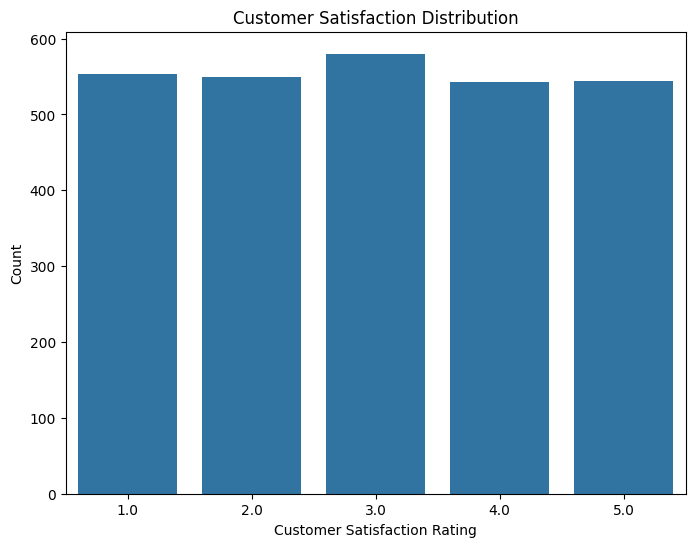

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Satisfaction Rating', data=df)
plt.title('Customer Satisfaction Distribution')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Count')
plt.show()

### Explanation:
This graph shows how many customers are satisfied and unsatisfied in the dataset.

### **2.2 Correlation Heatmap**

<function matplotlib.pyplot.show(close=None, block=None)>

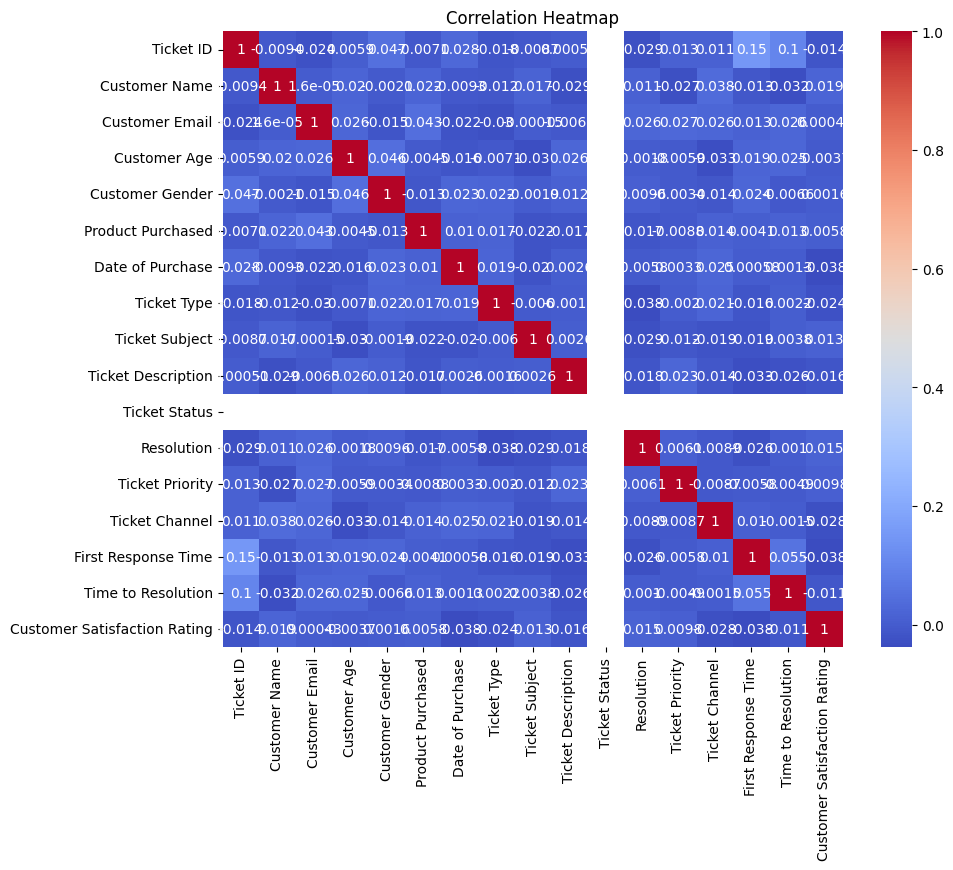

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title ('Correlation Heatmap')
plt.show

### Explanation:
The heatmap hepls identify relationships between different features and customer satisfaction.

## **STEP 3: FEATURE ENGINEERING**

In [ ]:
# Separating features and target variable

X = df.drop('Customer Satisfaction Rating', axis=1)
y = df['Customer Satisfaction Rating']

### Explanation:
The dataset is split into independent features (X) and target variable(Y).

### **STEP 4: MODEL BUILDING**

In [ ]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest Classifier
model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Explanation:
The data is split into training and testing sets, and a random forest model is trained using the training data.

## **STEP 5: MODEL EVALUATION**

### **5.1 Making Predication**

In [ ]:
# Making prediction on test data

y_pred = model.predict(X_test)

### **5.2 Model Performance**

In [ ]:
# Evaluating the model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.2292418772563177

Confusion Matrix:
 [[20 21 26 23 19]
 [25 26 36 10 20]
 [22 21 38 18 13]
 [18 16 23 25 26]
 [16 16 30 28 18]]


### Explanation:
Accuracy and classification metrics are used to evaluate the performance of the model.

## **STEP 6: VISUALIZATION (FEATURE IMPORTANCE)**

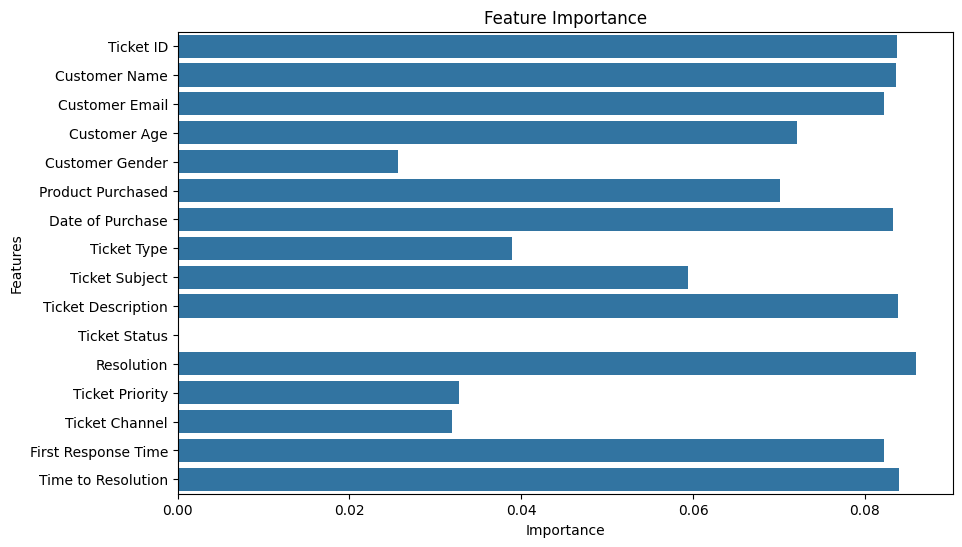

In [ ]:
# Visualizing feature importance

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

### Explanation:
This visualization shows which features contribute the most to predicting customer satisfaction.

## **SUMMARY:**

This project focuses on predicting customer satisfaction using
machine learning techniques. The dataset was first cleaned and
preprocessed to handle missing values and convert categorical
features into numerical form.

Exploratory Data Analysis (EDA) was performed to understand the
distribution of customer satisfaction and identify important
patterns in the data. Feature engineering helped in separating
input features and the target variable for model training.

A Random Forest Classifier was used to build the prediction model.
The dataset was divided into training and testing sets, and the
model was trained on historical customer data. Model performance
was evaluated using accuracy and classification metrics.

The results show that the model is able to predict customer
satisfaction effectively and also highlights key factors that
influence customer satisfaction. This project demonstrates a
complete end-to-end machine learning workflow suitable for
real-world business applications.

---

